In [1]:
# ============================================================
# ADIM 1: Google Drive'ı Bağla
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive bağlandı!")

Mounted at /content/drive
✅ Drive bağlandı!


In [2]:
# ============================================================
# ADIM 2: Zip Dosyasını Bul ve Aç
# ============================================================
import os
from pathlib import Path

# Drive'daki zip dosyasının yolu
# NOT: Eğer Drive'da farklı bir klasöre yüklediysen yolu değiştir
ZIP_PATH = "/content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip"
EXTRACT_PATH = "/content/dataset"

# Zip dosyası var mı kontrol et
if os.path.exists(ZIP_PATH):
    print(f"✅ Zip bulundu: {ZIP_PATH}")
    print(f"   Boyut: {os.path.getsize(ZIP_PATH) / (1024**3):.2f} GB")
else:
    print(f"❌ Zip bulunamadı: {ZIP_PATH}")
    print("   Drive'daki gerçek yolu bulmak için aşağıyı çalıştır:")
    import subprocess
    result = subprocess.run(['find', '/content/drive/MyDrive', '-name', '*.zip'],
                          capture_output=True, text=True)
    print(result.stdout)

✅ Zip bulundu: /content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip
   Boyut: 2.70 GB


In [3]:
# ============================================================
# ADIM 3: Zip'i Aç (sadece bir kez çalıştır, ~5-10 dakika sürer)
# ============================================================
import zipfile

if not os.path.exists(EXTRACT_PATH):
    print("📦 Zip açılıyor... (bu biraz sürebilir)")
    os.makedirs(EXTRACT_PATH, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Zip başarıyla açıldı!")
else:
    print("✅ Dataset zaten açık, tekrar açmaya gerek yok.")

# İçeriği göster
print("\n📁 Dataset içeriği:")
for item in Path(EXTRACT_PATH).rglob("*"):
    depth = len(item.relative_to(EXTRACT_PATH).parts)
    if depth <= 3 and item.is_dir():
        print("  " * depth + f"📂 {item.name}/")

📦 Zip açılıyor... (bu biraz sürebilir)
✅ Zip başarıyla açıldı!

📁 Dataset içeriği:
  📂 MultiRes_ConfocFluo_HumanDentin/
    📂 ImagePatches128/
    📂 RawImages/
    📂 RegisteredImages/
      📂 Classified/
      📂 Sample01/
      📂 Sample01/


In [4]:
# ============================================================
# ADIM 4: Sınıf ve Çözünürlük Bazında Dosya Sayıları
# ============================================================
import os
from pathlib import Path
from collections import OrderedDict

EXTRACT_PATH = "/content/dataset"

# Dataset kök klasörünü bul
dataset_root = None
for item in Path(EXTRACT_PATH).rglob("ImagePatches128"):
    dataset_root = item.parent
    break

if dataset_root is None:
    print("❌ ImagePatches128 klasörü bulunamadı!")
    print("Mevcut yapı:")
    for p in Path(EXTRACT_PATH).rglob("*"):
        if p.is_dir():
            depth = len(p.relative_to(EXTRACT_PATH).parts)
            if depth <= 4:
                print("  " * depth + p.name + "/")
else:
    print(f"✅ Dataset kök: {dataset_root}")
    patches_root = dataset_root / "ImagePatches128" / "Classified"

    print("\n" + "="*45)
    print(f"{'Sınıf':<12} {'Çözünürlük':<12} {'Dosya Sayısı':>12}")
    print("="*45)

    toplam = 0
    sinif_toplam = {}

    for sinif in ["tubules", "branches", "both"]:
        sinif_toplam[sinif] = 0
        for coz in ["HR", "x2", "x4", "x8"]:
            klasor = patches_root / sinif / coz
            if klasor.exists():
                sayi = len(list(klasor.glob("*.tif"))) + \
                       len(list(klasor.glob("*.tiff")))
                sinif_toplam[sinif] += sayi
                toplam += sayi
                print(f"{sinif:<12} {coz:<12} {sayi:>12}")
            else:
                print(f"{sinif:<12} {coz:<12} {'BULUNAMADI':>12}")
        print("-"*45)

    print(f"\n{'Sınıf Toplamları':}")
    for sinif, sayi in sinif_toplam.items():
        oran = sayi / toplam * 100 if toplam > 0 else 0
        print(f"  {sinif:<12}: {sayi:>6} patch  (%{oran:.1f})")

    print(f"\n  GENEL TOPLAM : {toplam:>6} patch")
    print("="*45)

✅ Dataset kök: /content/dataset/MultiRes_ConfocFluo_HumanDentin

Sınıf        Çözünürlük   Dosya Sayısı
tubules      HR                   5201
tubules      x2                   5201
tubules      x4                   5201
tubules      x8                   5201
---------------------------------------------
branches     HR                  32010
branches     x2                  32010
branches     x4                  32010
branches     x8                  32010
---------------------------------------------
both         HR                  53253
both         x2                  53253
both         x4                  53253
both         x8                  53253
---------------------------------------------

Sınıf Toplamları
  tubules     :  20804 patch  (%5.7)
  branches    : 128040 patch  (%35.4)
  both        : 213012 patch  (%58.9)

  GENEL TOPLAM : 361856 patch


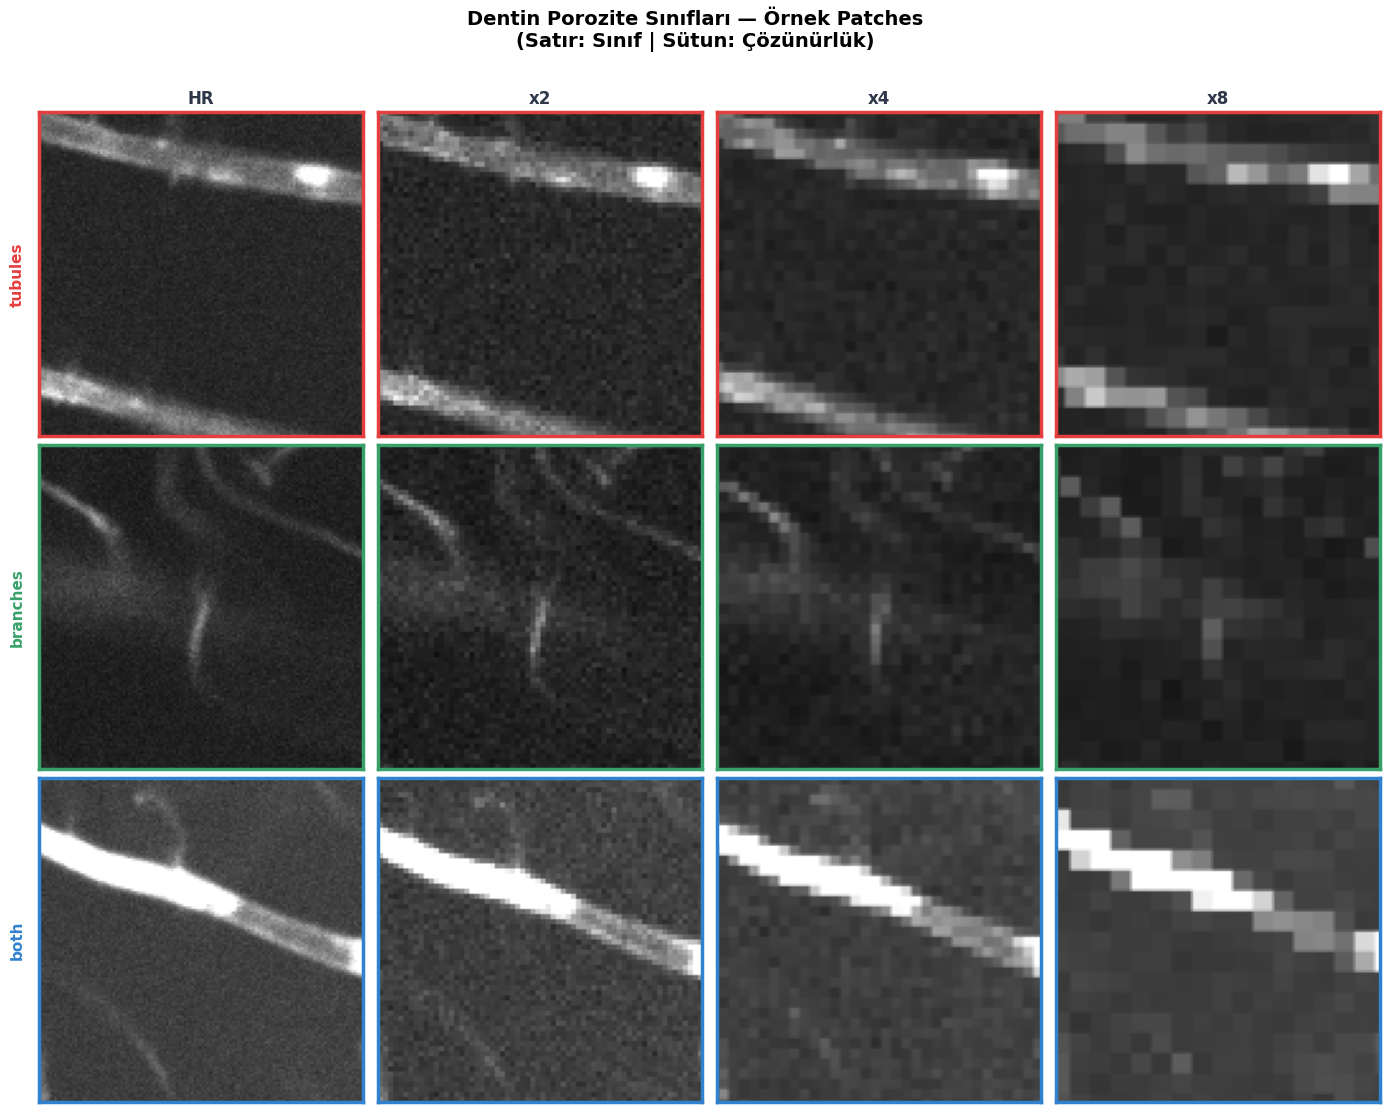

✅ Görsel kaydedildi: ornek_patchler.png


In [5]:
# ============================================================
# ADIM 5: Örnek Görüntüleri Görselleştir
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path
import tifffile

DATASET_ROOT = Path("/content/dataset/MultiRes_ConfocFluo_HumanDentin")
patches_root = DATASET_ROOT / "ImagePatches128" / "Classified"

siniflar = ["tubules", "branches", "both"]
cozunurlukler = ["HR", "x2", "x4", "x8"]
sinif_renkleri = {"tubules": "#E53E3E", "branches": "#38A169", "both": "#3182CE"}

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
fig.suptitle("Dentin Porozite Sınıfları — Örnek Patches\n(Satır: Sınıf | Sütun: Çözünürlük)",
             fontsize=14, fontweight='bold', y=1.01)

for i, sinif in enumerate(siniflar):
    for j, coz in enumerate(cozunurlukler):
        klasor = patches_root / sinif / coz
        dosyalar = list(klasor.glob("*.tif"))[:1]

        ax = axes[i, j]

        if dosyalar:
            img = tifffile.imread(str(dosyalar[0]))
            ax.imshow(img, cmap='gray', vmin=0, vmax=255)

        # Başlık
        if i == 0:
            ax.set_title(f"{coz}", fontsize=12, fontweight='bold',
                        color='#2D3748')
        # Sınıf etiketi (sol taraf)
        if j == 0:
            ax.set_ylabel(sinif, fontsize=11, fontweight='bold',
                         color=sinif_renkleri[sinif], rotation=90,
                         labelpad=10)

        # Çerçeve rengi sınıfa göre
        for spine in ax.spines.values():
            spine.set_edgecolor(sinif_renkleri[sinif])
            spine.set_linewidth(2.5)

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig("ornek_patchler.png", dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Görsel kaydedildi: ornek_patchler.png")

/tmp/ipykernel_3335/2618069080.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


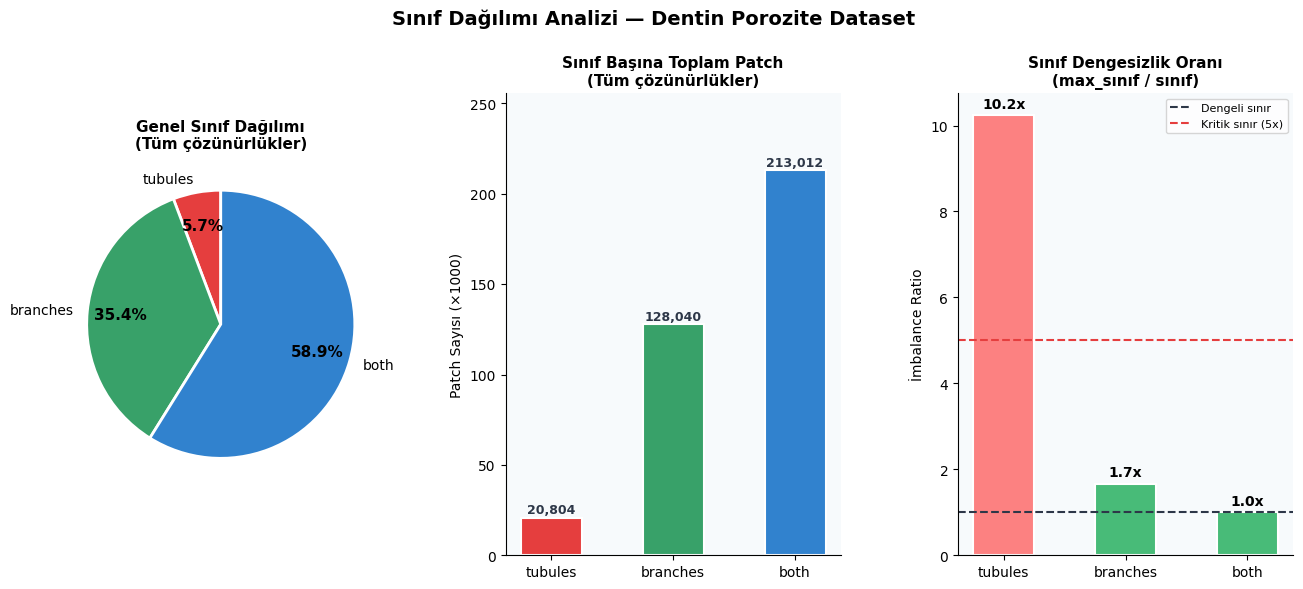

✅ Görsel kaydedildi: sinif_dagilimi.png

WEIGHTED LOSS İÇİN AĞIRLIKLAR
  tubules     : 2.3807
  branches    : 0.3868
  both        : 0.2325

Bu ağırlıklar modeli eğitirken kullanılacak.


In [6]:
# ============================================================
# ADIM 6: Sınıf Dağılımı Görselleştirme
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Veriler (az önce ölçtüğümüz sayılar)
siniflar = ["tubules", "branches", "both"]
cozunurlukler = ["HR", "x2", "x4", "x8"]
sayilar = {
    "tubules":  [5201, 5201, 5201, 5201],
    "branches": [32010, 32010, 32010, 32010],
    "both":     [53253, 53253, 53253, 53253],
}
renkler = {"tubules": "#E53E3E", "branches": "#38A169", "both": "#3182CE"}

fig = plt.figure(figsize=(16, 6))
fig.suptitle("Sınıf Dağılımı Analizi — Dentin Porozite Dataset",
             fontsize=14, fontweight='bold', y=1.02)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── GRAFIK 1: Genel pasta grafiği ──────────────────────────
ax1 = fig.add_subplot(gs[0])
toplam_sinif = [sum(v) for v in sayilar.values()]
renkler_list = [renkler[s] for s in siniflar]
wedges, texts, autotexts = ax1.pie(
    toplam_sinif,
    labels=siniflar,
    colors=renkler_list,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')
ax1.set_title("Genel Sınıf Dağılımı\n(Tüm çözünürlükler)",
              fontweight='bold', fontsize=11)

# ── GRAFIK 2: Sınıf başına patch sayısı (bar) ─────────────
ax2 = fig.add_subplot(gs[1])
bars = ax2.bar(siniflar, [s/1000 for s in toplam_sinif],
               color=renkler_list, edgecolor='white', linewidth=1.5,
               width=0.5)
ax2.set_title("Sınıf Başına Toplam Patch\n(Tüm çözünürlükler)",
              fontweight='bold', fontsize=11)
ax2.set_ylabel("Patch Sayısı (×1000)", fontsize=10)
ax2.set_ylim(0, max(toplam_sinif)/1000 * 1.2)

# Değerleri barların üstüne yaz
for bar, val in zip(bars, toplam_sinif):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:,}', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color='#2D3748')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_facecolor('#F7FAFC')

# ── GRAFIK 3: Dengesizlik uyarısı — imbalance ratio ────────
ax3 = fig.add_subplot(gs[2])
max_sinif = max(toplam_sinif)
oranlar = [max_sinif / s for s in toplam_sinif]
bar_colors = ['#48BB78' if o < 2 else '#F6AD55' if o < 5 else '#FC8181'
              for o in oranlar]
bars2 = ax3.bar(siniflar, oranlar, color=bar_colors,
                edgecolor='white', linewidth=1.5, width=0.5)
ax3.axhline(y=1, color='#2D3748', linestyle='--', linewidth=1.5,
            label='Dengeli sınır')
ax3.axhline(y=5, color='#E53E3E', linestyle='--', linewidth=1.5,
            label='Kritik sınır (5x)')
ax3.set_title("Sınıf Dengesizlik Oranı\n(max_sınıf / sınıf)",
              fontweight='bold', fontsize=11)
ax3.set_ylabel("İmbalance Ratio", fontsize=10)
ax3.legend(fontsize=8)

for bar, oran in zip(bars2, oranlar):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{oran:.1f}x', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_facecolor('#F7FAFC')

plt.tight_layout()
plt.savefig("sinif_dagilimi.png", dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Görsel kaydedildi: sinif_dagilimi.png")

# Weighted loss ağırlıklarını hesapla
print("\n" + "="*45)
print("WEIGHTED LOSS İÇİN AĞIRLIKLAR")
print("="*45)
import torch
sayi_tensor = torch.tensor(toplam_sinif, dtype=torch.float)
agirliklar = 1.0 / sayi_tensor
agirliklar = agirliklar / agirliklar.sum() * len(siniflar)
for sinif, agirlik in zip(siniflar, agirliklar):
    print(f"  {sinif:<12}: {agirlik:.4f}")
print("\nBu ağırlıklar modeli eğitirken kullanılacak.")
print("="*45)
